# W02A Descriptive Statistics in Python
## Notebook 2 of 2: Distributions, Outliers, and Relationships

**ENGR 1451/2451: Exploratory Data Science**

The Beamer slides explain how to interpret plots. This notebook focuses on the Python used to create and interrogate them.

By the end, you should be able to:

- calculate quartiles, IQR, and Tukey outlier fences;
- create and interpret histograms and boxplots;
- compare symmetric and skewed distributions;
- use grouped plots to reveal hidden structure;
- create labeled scatter plots for two quantitative variables; and
- use Anscombe's quartet to explain why plots must accompany numerical summaries.

## 1. Anscombe's quartet

Anscombe's quartet provides a transition from summary statistics to data visualization: datasets can have nearly identical numerical summaries while looking very different. The four datasets have nearly identical basic summaries but very different scatter plots.

In [5]:
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path

anscombe = pd.read_csv("./data/anscombe.csv")
anscombe = anscombe.drop(columns=["index"], errors="ignore")

anscombe.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [6]:
anscombe_summary = (
    anscombe.groupby("dataset")
    .agg(
        x_mean=("x", "mean"),
        x_sample_SD=("x", "std"),
        y_mean=("y", "mean"),
        y_sample_SD=("y", "std"),
    )
)

anscombe_summary

,x_mean,x_sample_SD,y_mean,y_sample_SD
dataset,,,,
I,9.0,3.316625,7.500909,2.031568
II,9.0,3.316625,7.500909,2.031657
III,9.0,3.316625,7.500000,2.030424
IV,9.0,3.316625,7.500909,2.030579


We will create four scatter plots, one for each dataset in Anscombe's quartet.

* `plt.subplots(2, 2)` creates a **2 × 2 grid** of plots.
* `sharex=True` and `sharey=True` give all four plots the same axis scales so they can be compared directly.
* `anscombe["dataset"].unique()` returns the four dataset labels.
* `axes` contains the four plots in a 2 × 2 grid. `axes.flat` lets us loop through those plots one at a time.
* `zip()` pairs each dataset with one plotting area.
* Inside the loop, we select one dataset at a time and plot its `x` and `y` values.
* `fig.suptitle()` adds a title for the entire figure.
* `fig.tight_layout()` adjusts the spacing so the plots and labels do not overlap.

The key idea is that the four datasets have very similar numerical summaries but look very different when visualized.


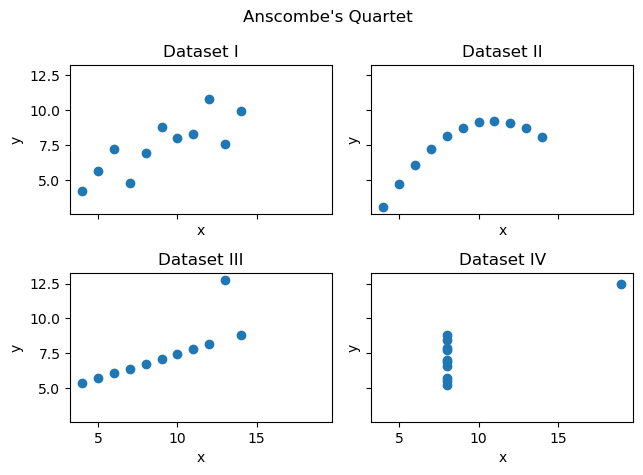

In [7]:
fig, axes = plt.subplots(
    2,
    2,
    sharex=True,
    sharey=True,
)

for dataset, axis in zip(
    anscombe["dataset"].unique(),
    axes.flat,
):
    subset = anscombe[anscombe["dataset"] == dataset]
    axis.scatter(subset["x"], subset["y"])
    axis.set_title(f"Dataset {dataset}")
    axis.set_xlabel("x")
    axis.set_ylabel("y")

fig.suptitle("Anscombe's Quartet")
fig.tight_layout()
plt.show()

## 2. Quartiles, IQR, and outlier fences

For one quantitative variable:

$$
\mathrm{IQR}=Q_3-Q_1.
$$

Tukey's common rule flags observations below $Q_1-1.5\,\mathrm{IQR}$ or above $Q_3+1.5\,\mathrm{IQR}$.

## 3. Boxplots

A boxplot compresses the median, quartiles, IQR, whiskers, and flagged outliers into one display. It is especially useful for comparing groups on a common scale. Pandas uses Tukey’s IQR rule.




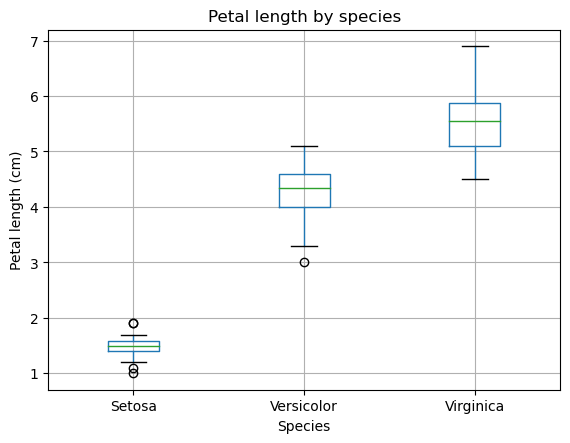

In [8]:
data_path = Path("./data/iris.csv")
iris = pd.read_csv(data_path)

ax = iris.boxplot(column="petal.length", by="variety")
plt.suptitle("")
ax.set_title("Petal length by species")
ax.set_xlabel("Species")
ax.set_ylabel("Petal length (cm)")
plt.show()

## 4. Histograms and bin choice

A histogram summarizes one quantitative variable. With equal-width bins, bar height is proportional to frequency. Bin width changes the appearance, so inspect more than one reasonable choice when the conclusion is sensitive.

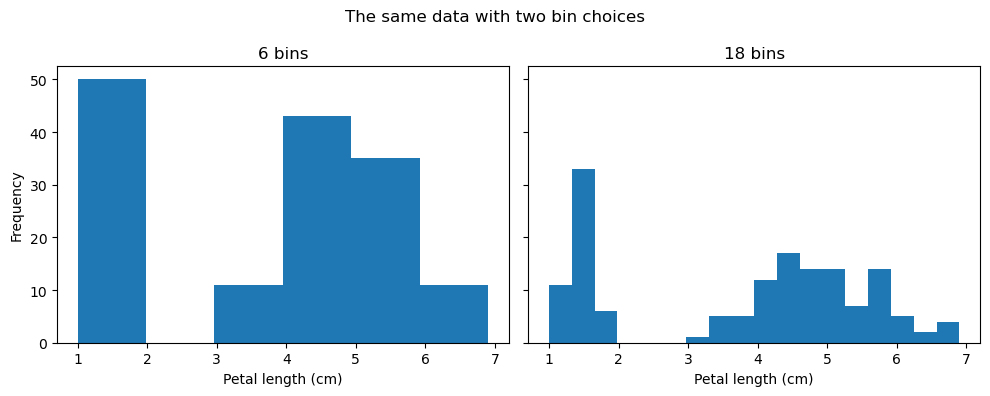

In [9]:
coarse_bins = 6
fine_bins = 18
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharey=True
)

iris["petal.length"].plot.hist(
    bins=coarse_bins,
    ax=axes[0]
)
axes[0].set_title(f"{coarse_bins} bins")
axes[0].set_xlabel("Petal length (cm)")
axes[0].set_ylabel("Frequency")

iris["petal.length"].plot.hist(
    bins=fine_bins,
    ax=axes[1]
)
axes[1].set_title(f"{fine_bins} bins")
axes[1].set_xlabel("Petal length (cm)")

fig.suptitle("The same data with two bin choices")
fig.tight_layout()

plt.show()

## 5. A pooled histogram can hide groups

The overall Iris histogram is multimodal because it combines species with different petal-length distributions. Separate plots reveal the source of the multiple peaks.

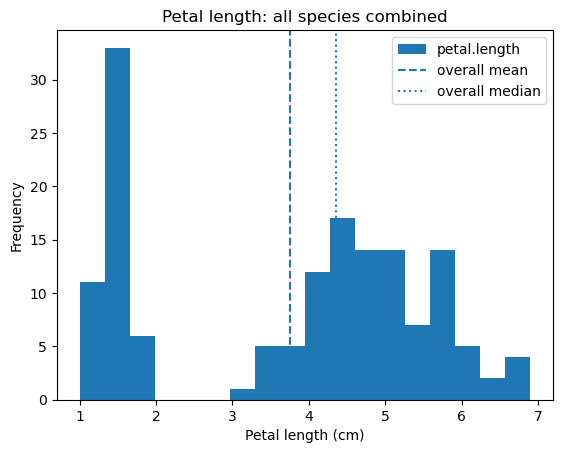

In [10]:
MEAN_LINE_STYLE = "--"
MEDIAN_LINE_STYLE = ":"

ax = iris["petal.length"].plot.hist(
    bins=fine_bins,
)
ax.axvline(
    iris["petal.length"].mean(),
    linestyle=MEAN_LINE_STYLE,
    label="overall mean",
)
ax.axvline(
    iris["petal.length"].median(),
    linestyle=MEDIAN_LINE_STYLE,
    label="overall median",
)
ax.set_title("Petal length: all species combined")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

## 6. Scatter plots and relationships

### Color reveals species clusters

Plot one group at a time so the legend and colors identify the species.


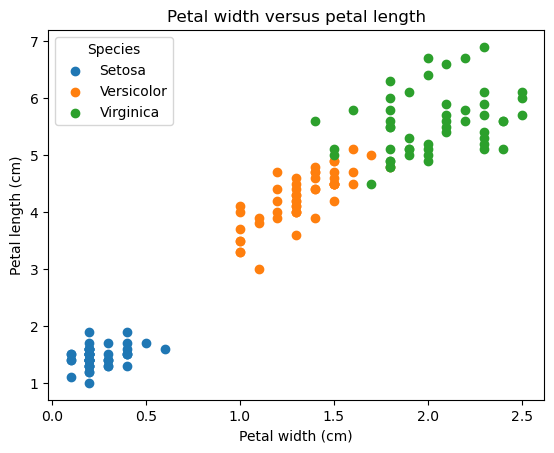

In [11]:
fig, ax = plt.subplots()

for species, group in iris.groupby("variety"):
    ax.scatter(
        group["petal.width"],
        group["petal.length"],
        label=species,
    )

ax.set_title("Petal width versus petal length")
ax.set_xlabel("Petal width (cm)")
ax.set_ylabel("Petal length (cm)")
ax.legend(title="Species")
plt.show()

## 7. Compact code reference

| Goal | Python pattern |
|---|---|
| Quartiles | `s.quantile([0.25, 0.50, 0.75])` |
| IQR | `s.quantile(0.75) - s.quantile(0.25)` |
| Flag outside fences | `s[(s < lower) | (s > upper)]` |
| Histogram | `s.plot.hist(bins=...)` |
| Boxplot | `df.boxplot(column="value", by="group")` |
| Scatter plot | `df.plot.scatter(x="x", y="y")` |
| Grouped summaries | `df.groupby("group")["value"].agg(...)` |

## 8. Your turn

Complete these tasks during class.

Q1 = 5.1
Q3 = 6.4
IQR = 1.3000000000000007
lower = 3.1499999999999986
upper = 8.350000000000001
number outside fences = 0
no observations outside the fences


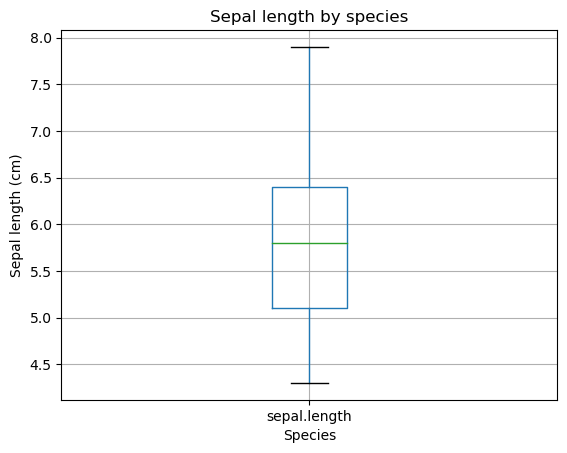

In [33]:
# YOUR TURN 1
# For sepal.length, calculate Q1, Q3, IQR, and the 1.5×IQR fences.
# Report any observations outside the fences.

s = iris["sepal.length"]

q1,q2,q3 = s.quantile([0.25, 0.5, 0.75])

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Q1 =",q1)
print("Q3 =",q3)
print("IQR =",iqr)

print("lower =", lower)
print("upper =", upper)

outside = s[(s < lower) | (s > upper)]
print("number outside fences =", len(outside))
if len(outside):
    print(outside)
else:
    print("no observations outside the fences")

ax = iris.boxplot(column="sepal.length")
plt.suptitle("")
ax.set_title("Sepal length by species")
ax.set_xlabel("Species")
ax.set_ylabel("Sepal length (cm)")
plt.show()

In [28]:
s = iris[["sepal.length","sepal.width"]]
print(s)

     sepal.length  sepal.width
0             5.1          3.5
1             4.9          3.0
2             4.7          3.2
3             4.6          3.1
4             5.0          3.6
..            ...          ...
145           6.7          3.0
146           6.3          2.5
147           6.5          3.0
148           6.2          3.4
149           5.9          3.0

[150 rows x 2 columns]


## Reproducibility check

Restart the kernel and run all cells. A first exploratory pass should combine **structure + center + spread + shape + outliers + groups + relationships**, supported by both numerical summaries and plots.